In [38]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-fjoeathx
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-fjoeathx
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.5 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=8e84a3e812102035119fdec848f65876786a52256a9d1db0af367115b0993391
  Stored in directory: /tmp/pip-ephem-wheel-cache-ms0x89y2/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("javierurea/simplified-mm-imdb")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/javierurea/simplified-mm-imdb


In [3]:
import numpy as np

data = np.load(f"{path}/data.npy", allow_pickle=True)

print(type(data))
print(data.shape)
print(data[0])

genres_list = [
    'Drama',
    'Comedy',
    'Romance',
    'Thriller',
    'Crime',
    'Action',
    'Adventure',
    'Horror',
    'Documentary',
    'Mystery',
    'Sci-Fi',
    'Fantasy',
    'Family',
    'Biography',
    'War',
    'History',
    'Music',
    'Animation',
    'Musical',
    'Western',
    'Sport',
    'Short',
    'Film-Noir',
]

print(len(genres_list) == len(data[0][1]))

<class 'numpy.ndarray'>
(25959, 3)
[0
 list([1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])
 "sardonic detective shane , thrown out of one town for bringing trouble , heads for home and his ex - partner ' s detective agency . the business is in a sad way , and shane , who has had the forethought to provide himself with a N - dollar commission from an old lady on the train , is welcomed with open arms . when pretty valerie purvis walks in the next day willing to pay over the odds to put a tail on the man who did her wrong , shane ' s way with the ladies looks like paying off yet again . but things start to go wrong when his partner is murdered , and shane himself comes home to find his apartment wrecked by a gentlemanly crook who comes back to apologise - - and to tell him a fascinating fairy - story about the fabled horn of roland that looks like not being so mythical after all . miss purvis wants protection . the police want answers . and all sorts of people wan

In [13]:
data_path = path + '/data.npy'
image_path = path + '/images.npz'

Drama: 13967
Comedy: 8592
Romance: 5364
Thriller: 5192
Crime: 3838
Action: 3550
Adventure: 2710
Horror: 2703
Documentary: 2082
Mystery: 2057
Sci-Fi: 1991
Fantasy: 1933
Family: 1668
Biography: 1343
War: 1335
History: 1143
Music: 1045
Animation: 997
Musical: 841
Western: 705
Sport: 634
Short: 471
Film-Noir: 338


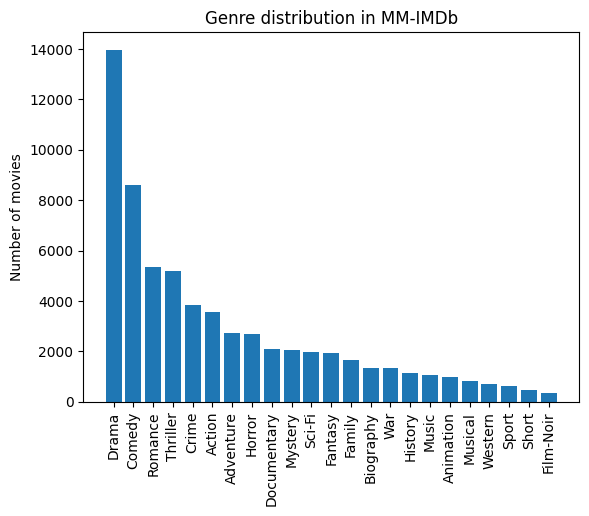

In [14]:
import numpy as np

labels = np.array([sample[1] for sample in data])
genre_counts = labels.sum(axis=0)

for g, count in zip(genres_list, genre_counts):
    print(f"{g}: {count}")

import matplotlib.pyplot as plt

plt.bar(genres_list, genre_counts)
plt.xticks(rotation=90)
plt.ylabel("Number of movies")
plt.title("Genre distribution in MM-IMDb")
plt.show()

In [15]:
num_labels_per_movie = labels.sum(axis=1)
print("Min genres per movie:", num_labels_per_movie.min())
print("Max genres per movie:", num_labels_per_movie.max())
print("Mean genres per movie:", num_labels_per_movie.mean())

Min genres per movie: 1
Max genres per movie: 10
Mean genres per movie: 2.484648869370931


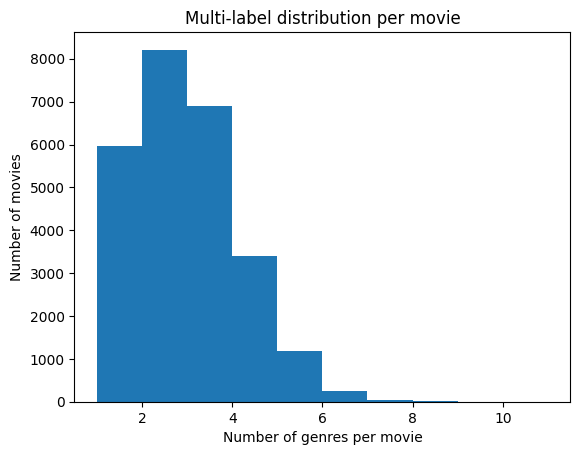

In [8]:
plt.hist(num_labels_per_movie, bins=range(1, num_labels_per_movie.max()+2))
plt.xlabel("Number of genres per movie")
plt.ylabel("Number of movies")
plt.title("Multi-label distribution per movie")
plt.show()

Min words: 1
Max words: 1887
Mean words: 124.41276628529604
Median words: 107.0


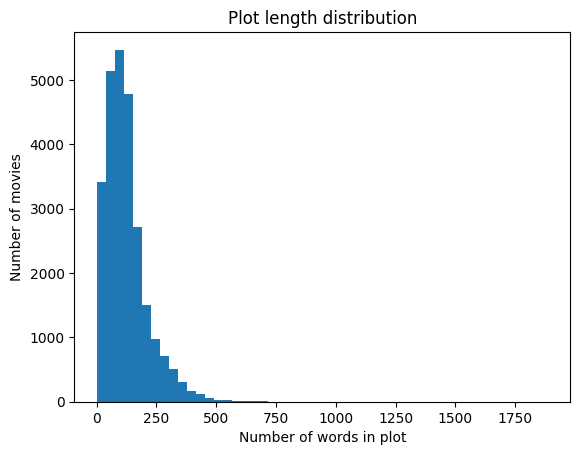

In [9]:
plot_lengths = [len(sample[2].split()) for sample in data]

print("Min words:", min(plot_lengths))
print("Max words:", max(plot_lengths))
print("Mean words:", np.mean(plot_lengths))
print("Median words:", np.median(plot_lengths))

plt.hist(plot_lengths, bins=50)
plt.xlabel("Number of words in plot")
plt.ylabel("Number of movies")
plt.title("Plot length distribution")
plt.show()

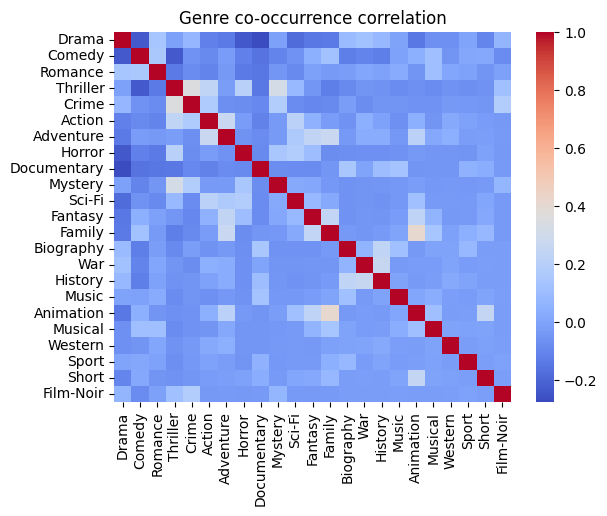

In [10]:
import seaborn as sns

cor_matrix = np.corrcoef(labels.T)  # 23x23 correlation
sns.heatmap(cor_matrix, xticklabels=genres_list, yticklabels=genres_list, cmap="coolwarm")
plt.title("Genre co-occurrence correlation")
plt.show()

In [16]:
idx_to_class = {i: g for i, g in enumerate(genres_list)}
class_to_idx = {g: i for i, g in idx_to_class.items()}
num_classes = len(genres_list)

In [18]:
from PIL import Image

In [19]:
import numpy as np

image_data = np.load(image_path)
print(image_data.files)  # check the keys

['images']


In [20]:
import numpy as np

image_data = np.load(image_path)
images = image_data['images']  # shape: (25959, H, W, 3)

print("Images shape:", images.shape)
print("Example image dtype:", images.dtype)


Images shape: (25959, 3, 256, 160)
Example image dtype: uint8


In [21]:
print(f"Min: {images.min()}, Max: {images.max()}")

Min: 0, Max: 255


In [16]:
ori_path = "/content/MV5BOWZjYTNiNjgtMmFlMi00ZTQyLTllMzAtMDA1YTFjYzJiNzI5XkEyXkFqcGc@._V1_.jpg"

In [22]:
import numpy as np
img = images[0]
print("Channel Means:", np.mean(img, axis=(1, 2)))
print("Channel Maxes:", np.max(img, axis=(1, 2)))

Channel Means: [ 87.42287598 122.49807129 129.8729248 ]
Channel Maxes: [255 255 255]


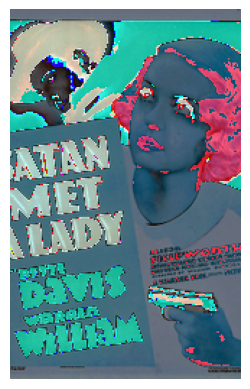

Error: no "view" mailcap rules found for type "image/png"
/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found
/usr/bin/xdg-open: 882: lynx: not found
/usr/bin/xdg-open: 882: w3m: not found
xdg-open: no method available for opening '/tmp/tmpwppnegdu.PNG'


In [23]:
import numpy as np
from PIL import Image

# 1. Start with your original sample
img = images[0]

# 2. Transpose to HWC (Height, Width, Channel)
img_hwc = np.transpose(img, (1, 2, 0))

# 3. SAFETY STEP: Clip values to ensure they stay between 0-255
# This prevents the "neon" overflow you saw in image 2
img_safe = np.clip(img_hwc, 0, 255)

# 4. Convert to uint8 and display
Image.fromarray(img_safe.astype(np.uint8)).show()

import matplotlib.pyplot as plt

plt.imshow(img_hwc)
plt.axis('off')
plt.show()

In [26]:
from torch.utils.data import Dataset, DataLoader
import torch
from PIL import Image

In [27]:
class MM_IMDB_Dataset(Dataset):
  def __init__(self, data_path,image_path,transform=None):
    self.data = np.load(data_path, allow_pickle=True)
    self.images = np.load(image_path, mmap_mode='r')['images']

    self.transform = transform

  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    image_idx, label, text = self.data[idx]

    img = self.images[image_idx]
    img = np.transpose(img, (1,2,0))
    if img.dtype != np.uint8:
      if img.max() <= 1:
        img = (img * 255).astype(np.uint8)
      else:
        img = img.astype(np.uint8)

    if self.transform:
      img = self.transform(img)

    label = torch.tensor(label, dtype=torch.float32)

    return img, label, text

In [28]:
from torchvision import transforms

clip_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(224, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.48145466, 0.4578275, 0.40821073),
        std=(0.26862954, 0.26130258, 0.27577711)
    )
])

In [29]:
dataset = MM_IMDB_Dataset(data_path, image_path,clip_transform)

In [31]:
#create sample of the dataset
from torch.utils.data import Subset

np.random.seed(42)

indices = np.random.choice(len(dataset), int(0.2 * len(dataset)), replace=False)
test_dataset = Subset(dataset, indices)

In [35]:
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [39]:
import clip
clip.available_models()

['RN50',
 'RN101',
 'RN50x4',
 'RN50x16',
 'RN50x64',
 'ViT-B/32',
 'ViT-B/16',
 'ViT-L/14',
 'ViT-L/14@336px']

In [40]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()

100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 184MiB/s]


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

In [41]:
text_prompts = [f"a movie poster of a {g} movie" for g in genres_list]
text_tokens = clip.tokenize(text_prompts).to(device)

with torch.no_grad():
    label_features = model.encode_text(text_tokens)
    label_features /= label_features.norm(dim=-1, keepdim=True)

In [42]:
from tqdm import tqdm

In [43]:
import torch
from sklearn.metrics import precision_score, recall_score, f1_score
from tqdm import tqdm

alpha = 0.2
threshold = 0.5

all_preds = []
all_targets = []

model.eval()

with torch.no_grad():
    for imgs, labels, texts in tqdm(test_loader):

        imgs = imgs.to(device)
        labels = labels.to(device)

        img_feat = model.encode_image(imgs)
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)

        text_tokens = clip.tokenize(list(texts), truncate=True).to(device)
        txt_feat = model.encode_text(text_tokens)
        txt_feat = txt_feat / txt_feat.norm(dim=-1, keepdim=True)

        fused_feat = alpha * img_feat + (1 - alpha) * txt_feat
        fused_feat = fused_feat / fused_feat.norm(dim=-1, keepdim=True)

        logits = fused_feat @ label_features.T

        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float()

        all_preds.append(preds.cpu())
        all_targets.append(labels.cpu())

all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

precision = precision_score(all_targets, all_preds, average="micro", zero_division=0)
recall = recall_score(all_targets, all_preds, average="micro", zero_division=0)
f1 = f1_score(all_targets, all_preds, average="micro", zero_division=0)

print({
    "precision": precision,
    "recall": recall,
    "f1": f1
})

100%|██████████| 163/163 [13:19<00:00,  4.90s/it]

{'precision': 0.10787064568274522, 'recall': 1.0, 'f1': 0.19473509132696262}


## Few-Shot Learning (Multi-modal)
Trong phần này, ta sẽ áp dụng Few-shot learning bằng cách sử dụng các vector đặc trưng trích xuất từ mô hình CLIP đóng băng (Linear Probing). Ta huấn luyện một mạng phân loại hồi quy Logistic trên tập mẫu rất nhỏ chứa ảnh và cốt truyện đã dung hợp.

In [32]:
# 1. Trích xuất đặc trưng tập Few-Shot Train (Support Set)
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
import matplotlib.pyplot as plt

# Tái tạo lại tập indices của Toàn bộ Data
all_indices = set(range(len(dataset)))
# Tập indices của Zero-shot test (20% dữ liệu)
test_idx_set = set(indices)

# Tập indices còn lại
available_train_indices = list(all_indices - test_idx_set)

# Chọn ngẫu nhiên 200 mẫu cho Few-shot training
num_shots = 200
np.random.seed(42)
few_shot_indices = np.random.choice(available_train_indices, num_shots, replace=False)

train_subset = Subset(dataset, few_shot_indices)
train_loader = DataLoader(train_subset, batch_size=32, shuffle=False)

print(f"Đã lấy {num_shots} mẫu cho Few-shot training.")

Đã lấy 200 mẫu cho Few-shot training.


In [33]:
# 2. Tính toán Vector Đặc Trưng cho Tập Train
print("Đang rút gọn đặc trưng Đa phương thức (Train set)...")
train_features_list = []
train_labels_list = []
model.eval()
with torch.no_grad():
    for imgs, labels, texts in tqdm(train_loader):
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        img_feat = model.encode_image(imgs)
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
        
        text_tokens = clip.tokenize(list(texts), truncate=True).to(device)
        txt_feat = model.encode_text(text_tokens)
        txt_feat = txt_feat / txt_feat.norm(dim=-1, keepdim=True)
        
        # Fusion giống Zero-shot
        fused_feat = alpha * img_feat + (1 - alpha) * txt_feat
        fused_feat = fused_feat / fused_feat.norm(dim=-1, keepdim=True)
        
        train_features_list.append(fused_feat.cpu())
        train_labels_list.append(labels.cpu())

train_features = torch.cat(train_features_list).numpy()
train_labels = torch.cat(train_labels_list).numpy()
print("Kích thước đặc trưng Train đa phương thức:", train_features.shape)

Đang rút gọn đặc trưng Đa phương thức (Train set)...


100%|██████████| 7/7 [00:00<00:00,  7.20it/s]

Kích thước đặc trưng Train đa phương thức: (200, 512)


In [34]:
# 3. Trích xuất đặc trưng Tập Test
print("Đang rút gọn đặc trưng Đa phương thức (Test set)...")
test_features_list = []
test_labels_list = []
with torch.no_grad():
    for imgs, labels, texts in tqdm(test_loader):
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        img_feat = model.encode_image(imgs)
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
        
        text_tokens = clip.tokenize(list(texts), truncate=True).to(device)
        txt_feat = model.encode_text(text_tokens)
        txt_feat = txt_feat / txt_feat.norm(dim=-1, keepdim=True)
        
        fused_feat = alpha * img_feat + (1 - alpha) * txt_feat
        fused_feat = fused_feat / fused_feat.norm(dim=-1, keepdim=True)
        
        test_features_list.append(fused_feat.cpu())
        test_labels_list.append(labels.cpu())

test_features = torch.cat(test_features_list).numpy()
test_labels = torch.cat(test_labels_list).numpy()
print("Kích thước đặc trưng Test đa phương thức:", test_features.shape)

Đang rút gọn đặc trưng Đa phương thức (Test set)...


100%|██████████| 163/163 [00:22<00:00,  7.19it/s]

Kích thước đặc trưng Test đa phương thức: (5191, 512)


In [36]:
# 4. Huấn luyện Logistic Classifier và Đánh giá (Few-shot)
print("Đang huấn luyện phân loại Logistic Regression (One-Vs-Rest) cho đa nhãn...")
clf = OneVsRestClassifier(LogisticRegression(max_iter=1000, solver='lbfgs', C=1.0))
# Fit Linear Model lên đặc trưng thay vì train lại mạng ảo
clf.fit(train_features, train_labels) 

print("Đang phân loại tập Test...")
fewshot_pred_probs = clf.predict_proba(test_features)

# Thử nghiệm các ngưỡng Threshold để lấy F1 cao nhất giống Zero-shot
thresholds = np.arange(0.1, 0.9, 0.1)
best_f1_fewshot = 0
best_thresh_fewshot = 0
best_fewshot_macro = 0
best_fewshot_precision = 0
best_fewshot_recall = 0

for t in thresholds:
    preds = (fewshot_pred_probs > t).astype(int)
    mi_f1 = f1_score(test_labels, preds, average="micro", zero_division=0)
    if mi_f1 > best_f1_fewshot:
        best_f1_fewshot = mi_f1
        best_thresh_fewshot = t
        best_fewshot_macro = f1_score(test_labels, preds, average="macro", zero_division=0)
        best_fewshot_precision = precision_score(test_labels, preds, average="micro", zero_division=0)
        best_fewshot_recall = recall_score(test_labels, preds, average="micro", zero_division=0)

print(f"Ngưỡng Tối Ưu Nhất Few-shot: {best_thresh_fewshot:.1f}")
print(f"Few-shot Micro Precision: {best_fewshot_precision:.4f}")
print(f"Few-shot Micro Recall: {best_fewshot_recall:.4f}")
print(f"Few-shot Micro F1: {best_f1_fewshot:.4f}")
print(f"Few-shot Macro F1: {best_fewshot_macro:.4f}")

Đang huấn luyện phân loại Logistic Regression (One-Vs-Rest) cho đa nhãn...
Đang phân loại tập Test...


/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 22 is present in all training examples.
  warnings.warn(


Ngưỡng Tối Ưu Nhất Few-shot: 0.3
Few-shot Micro Precision: 0.5103
Few-shot Micro Recall: 0.3647
Few-shot Micro F1: 0.4254
Few-shot Macro F1: 0.0757


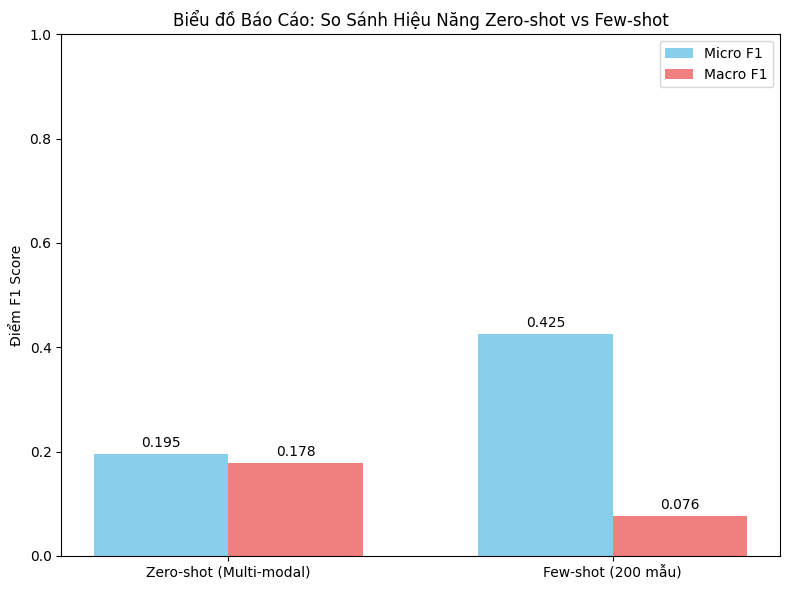

In [37]:
# 5. BIỂU ĐỒ SO SÁNH GIỮA ZERO-SHOT VÀ FEW-SHOT
# Tập hợp metric
zero_shot_f1 = f1  # Metric F1 cuối cùng của Zero-shot trên test_loader
zero_shot_macro = f1_score(all_targets, all_preds, average="macro", zero_division=0)

few_shot_f1 = best_f1_fewshot
few_shot_macro = best_fewshot_macro

# Config plotting
labels = ['Zero-shot (Multi-modal)', f'Few-shot ({num_shots} mẫu)']
micro_f1s = [zero_shot_f1, few_shot_f1]
macro_f1s = [zero_shot_macro, few_shot_macro]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, micro_f1s, width, label='Micro F1', color='skyblue')
rects2 = ax.bar(x + width/2, macro_f1s, width, label='Macro F1', color='lightcoral')

ax.set_ylabel('Điểm F1 Score')
ax.set_title('Biểu đồ Báo Cáo: So Sánh Hiệu Năng Zero-shot vs Few-shot')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.0)
ax.legend()

# Gắn nhãn Text giá trị lên thanh 
ax.bar_label(rects1, padding=3, fmt='%.3f')
ax.bar_label(rects2, padding=3, fmt='%.3f')

plt.tight_layout()
plt.show()